In [298]:
# Cell 1: load the JSONL summary file and build a combo-level summary across seeds

import json
import re
import pandas as pd

jsonl_path = "/home/akapociu/ift/interactiondynamics/results/wave/11.jsonl"

rows = []
with open(jsonl_path, "r") as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        rows.append(json.loads(line))

df = pd.DataFrame(rows)

# keep only wave just in case
df = df[df["dataset"] == "wave"].copy()

def extract_field(name, field):
    m = re.search(rf"{field}=([^|]+)", str(name))
    return m.group(1) if m else None

PRETTY_AGG = {
    "sum": "Sum",
    "deepsets": "DeepSets",
    "settransformer": "SetTransformer",
    "hopfield": "Hopfield",
    "ift": "IFT",
}

PRETTY_UPD = {
    "tgn_gru": "TGN-GRU",
    "ift_update": "IFT Update",
    "hopfield_update": "Hopfield Update",
    "hnn": "HNN",
    "lnn": "LNN",
    "identity": "Identity",
}

df["aggregator"] = df["name"].apply(lambda s: extract_field(s, "agg"))
df["update"] = df["name"].apply(lambda s: extract_field(s, "update"))

df["agg_pretty"] = df["aggregator"].map(PRETTY_AGG).fillna(df["aggregator"])
df["upd_pretty"] = df["update"].map(PRETTY_UPD).fillna(df["update"])

df["model_combo"] = df["agg_pretty"] + " × " + df["upd_pretty"]

summary_df = (
    df.groupby("model_combo", as_index=False)
      .agg(
          avg_best_val_mae=("best_val_mae", "mean"),
          std_best_val_mae=("best_val_mae", "std"),
          n_seeds=("seed", "nunique"),
      )
      .sort_values("avg_best_val_mae", ascending=True)
      .reset_index(drop=True)
)

summary_df

,model_combo,avg_best_val_mae,std_best_val_mae,n_seeds
0,IFT × IFT Update,0.452658,0.000087,3
1,IFT × TGN-GRU,0.473940,0.000148,3
2,IFT × Hopfield Update,0.479579,0.002604,3


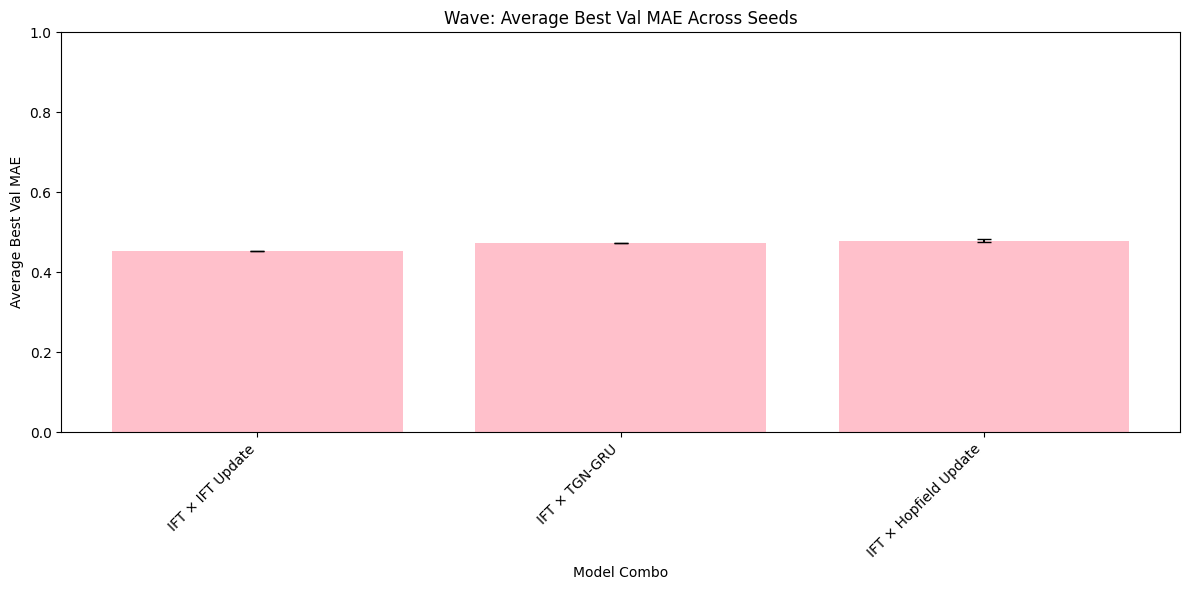

In [299]:
# Cell 2: bar chart of average best val MAE across seeds with std error bars

import matplotlib.pyplot as plt

plot_df = summary_df.copy()

plt.figure(figsize=(12, 6))
plt.bar(
    plot_df["model_combo"],
    plot_df["avg_best_val_mae"],
    yerr=plot_df["std_best_val_mae"].fillna(0.0),
    capsize=5,
    color="pink",
)

plt.ylabel("Average Best Val MAE")
plt.xlabel("Model Combo")
plt.title("Wave: Average Best Val MAE Across Seeds")
plt.ylim(0, 1)
#plt.ylim(0.4, 1.0)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [300]:
import numpy as np
import pandas as pd
from pathlib import Path
from scipy.stats import pearsonr, spearmanr

pred_dir = Path("/home/akapociu/ift/interactiondynamics/results/wave/11")

rows = []

for npz_path in sorted(pred_dir.glob("*.npz")):
    arr = np.load(npz_path)
    times = arr["times"]
    y_true = arr["y_true"]
    y_pred = arr["y_pred"]

    # flatten everything for global metrics
    true_flat = y_true.reshape(-1)
    pred_flat = y_pred.reshape(-1)

    mae = np.mean(np.abs(true_flat - pred_flat))
    rmse = np.sqrt(np.mean((true_flat - pred_flat) ** 2))

    std_true = np.std(true_flat)
    std_pred = np.std(pred_flat)
    std_ratio = std_pred / (std_true + 1e-12)

    # global Pearson / Spearman + slope
    if std_true < 1e-12 or std_pred < 1e-12:
        global_pearson = np.nan
        global_spearman = np.nan
        slope = np.nan
        intercept = np.nan
    else:
        global_pearson = pearsonr(true_flat, pred_flat)[0]
        global_spearman = spearmanr(true_flat, pred_flat)[0]
        slope, intercept = np.polyfit(true_flat, pred_flat, 1)
        
    # node-wise Pearson / Spearman
    T, N, D = y_true.shape
    node_pearsons = []
    node_spearmans = []

    for node_idx in range(N):
        for d in range(D):
            t_node = y_true[:, node_idx, d]
            p_node = y_pred[:, node_idx, d]

            if np.std(t_node) < 1e-12 or np.std(p_node) < 1e-12:
                continue

            node_pearsons.append(pearsonr(t_node, p_node)[0])
            node_spearmans.append(spearmanr(t_node, p_node)[0])

    mean_node_pearson = np.mean(node_pearsons) if node_pearsons else np.nan
    median_node_pearson = np.median(node_pearsons) if node_pearsons else np.nan

    mean_node_spearman = np.mean(node_spearmans) if node_spearmans else np.nan
    median_node_spearman = np.median(node_spearmans) if node_spearmans else np.nan

    rows.append({
        "file": npz_path.name,
        "mae": mae,
        "rmse": rmse,
        "global_pearson": global_pearson,
        "global_spearman": global_spearman,
        "mean_node_pearson": mean_node_pearson,
        "median_node_pearson": median_node_pearson,
        "mean_node_spearman": mean_node_spearman,
        "median_node_spearman": median_node_spearman,
        "std_true": std_true,
        "std_pred": std_pred,
        "std_ratio": std_ratio,
        "slope": slope,
        "intercept": intercept,
    })


metrics_df = pd.DataFrame(rows)

#display(metrics_df.sort_values("mean_node_pearson", ascending=False))

In [301]:
import re

PRETTY_AGG = {
    "sum": "Sum",
    "deepsets": "DeepSets",
    "settransformer": "SetTransformer",
    "hopfield": "Hopfield",
    "ift": "IFT",
}

PRETTY_UPD = {
    "tgn_gru": "TGN-GRU",
    "ift_update": "IFT Update",
    "hopfield_update": "Hopfield Update",
    "hnn": "HNN",
    "lnn": "LNN",
    "identity": "Identity",
}

def extract_field(text, field):
    m = re.search(rf"{field}-([^_]+)", str(text))
    return m.group(1) if m else None

def pretty_combo_from_filename(fname):
    agg = extract_field(fname, "agg")
    upd = extract_field(fname, "update")

    agg_pretty = PRETTY_AGG.get(agg, agg if agg is not None else "UnknownAgg")
    upd_pretty = PRETTY_UPD.get(upd, upd if upd is not None else "UnknownUpd")

    return f"{agg_pretty} × {upd_pretty}"

metrics_df["model_combo"] = metrics_df["file"].apply(pretty_combo_from_filename)
#metrics_df

In [302]:
combo_corr_df = (
    metrics_df
    .groupby("model_combo", as_index=False)
    .agg(
        avg_mean_node_pearson=("mean_node_pearson", "mean"),
        std_mean_node_pearson=("mean_node_pearson", "std"),
        n_files=("file", "count"),
    )
    .sort_values("avg_mean_node_pearson", ascending=False)
    .reset_index(drop=True)
)

combo_corr_df

,model_combo,avg_mean_node_pearson,std_mean_node_pearson,n_files
0,IFT × ift,0.347895,0.000123,3
1,IFT × tgn,0.227197,0.010421,3
2,IFT × hopfield,0.194637,0.011858,3


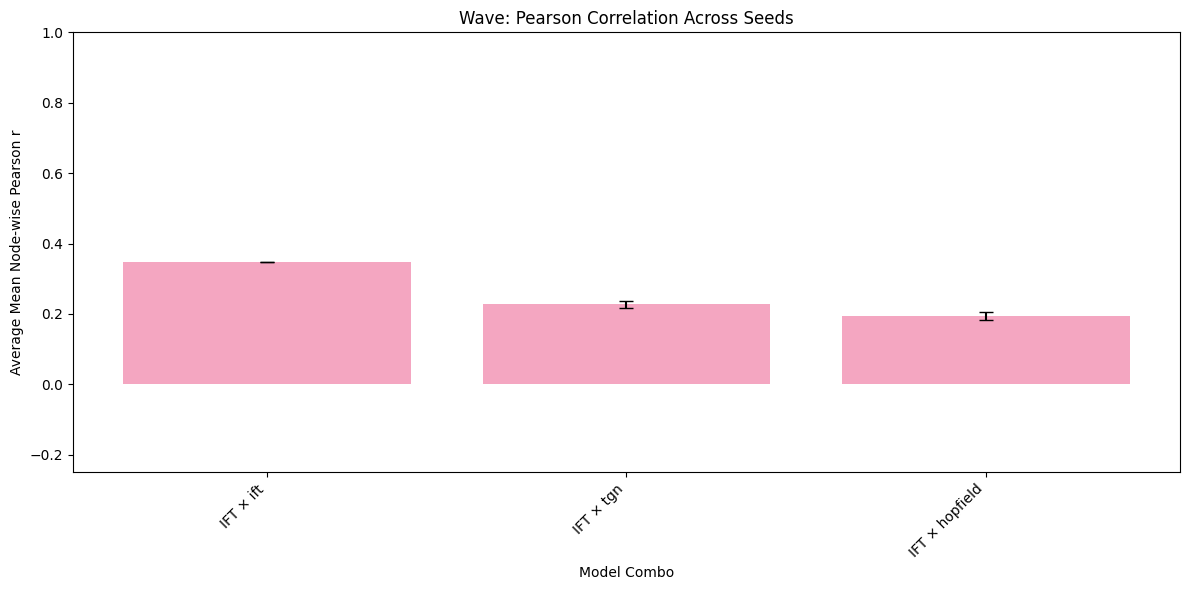

In [303]:
import matplotlib.pyplot as plt

plot_df = combo_corr_df.copy()

plt.figure(figsize=(12, 6))
plt.bar(
    plot_df["model_combo"],
    plot_df["avg_mean_node_pearson"],
    yerr=plot_df["std_mean_node_pearson"].fillna(0.0),
    capsize=5,
    color="#f4a6c1",
)

plt.ylabel("Average Mean Node-wise Pearson r")
plt.xlabel("Model Combo")
plt.title("Wave: Pearson Correlation Across Seeds")
plt.ylim(-0.25, 1.0)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [304]:
combo_spear_df = (
    metrics_df
    .groupby("model_combo", as_index=False)
    .agg(
        avg_mean_node_spearman=("mean_node_spearman", "mean"),
        std_mean_node_spearman=("mean_node_spearman", "std"),
        n_files=("file", "count"),
    )
    .sort_values("avg_mean_node_spearman", ascending=False)
    .reset_index(drop=True)
)

combo_spear_df

,model_combo,avg_mean_node_spearman,std_mean_node_spearman,n_files
0,IFT × ift,0.206400,0.005893,3
1,IFT × hopfield,0.124045,0.007717,3
2,IFT × tgn,0.101615,0.004616,3


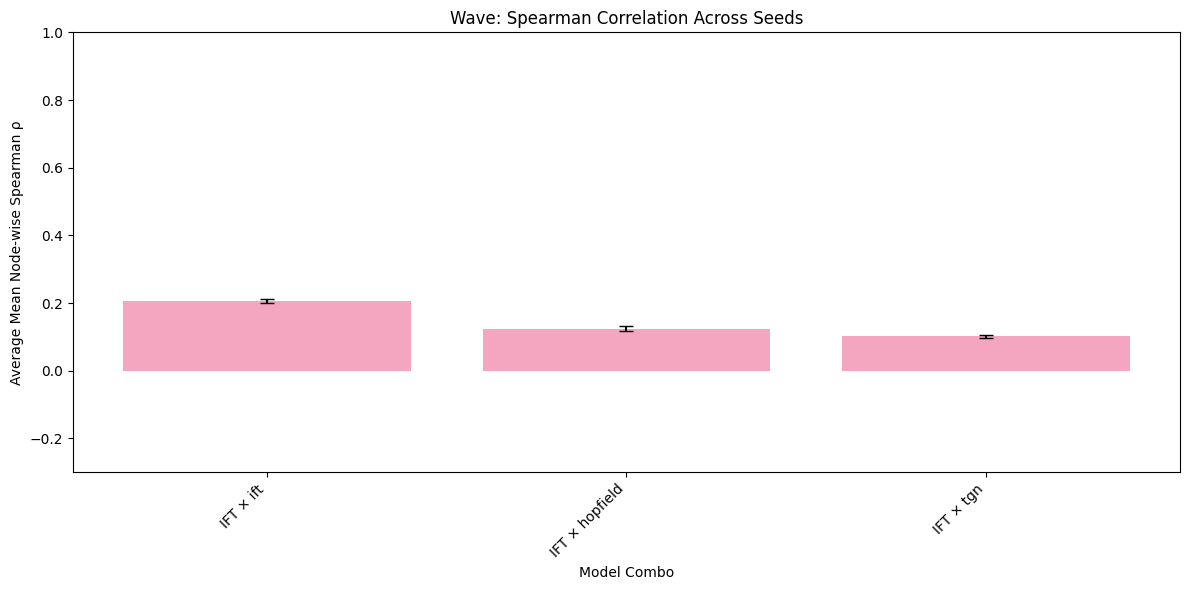

In [305]:
import matplotlib.pyplot as plt

plot_df = combo_spear_df.copy()

plt.figure(figsize=(12, 6))
plt.bar(
    plot_df["model_combo"],
    plot_df["avg_mean_node_spearman"],
    yerr=plot_df["std_mean_node_spearman"].fillna(0.0),
    capsize=5,
    color="#f4a6c1",
)

plt.ylabel("Average Mean Node-wise Spearman ρ")
plt.xlabel("Model Combo")
plt.title("Wave: Spearman Correlation Across Seeds")
plt.ylim(-0.3, 1.0)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [306]:
combo_ratio_df = (
    metrics_df
    .groupby("model_combo", as_index=False)
    .agg(
        avg_std_ratio=("std_ratio", "mean"),
        std_std_ratio=("std_ratio", "std"),
        n_files=("file", "count"),
    )
    .sort_values("avg_std_ratio", ascending=False)
    .reset_index(drop=True)
)

combo_ratio_df

,model_combo,avg_std_ratio,std_std_ratio,n_files
0,IFT × ift,0.440447,0.001754,3
1,IFT × hopfield,0.387195,0.017427,3
2,IFT × tgn,0.302829,0.006079,3


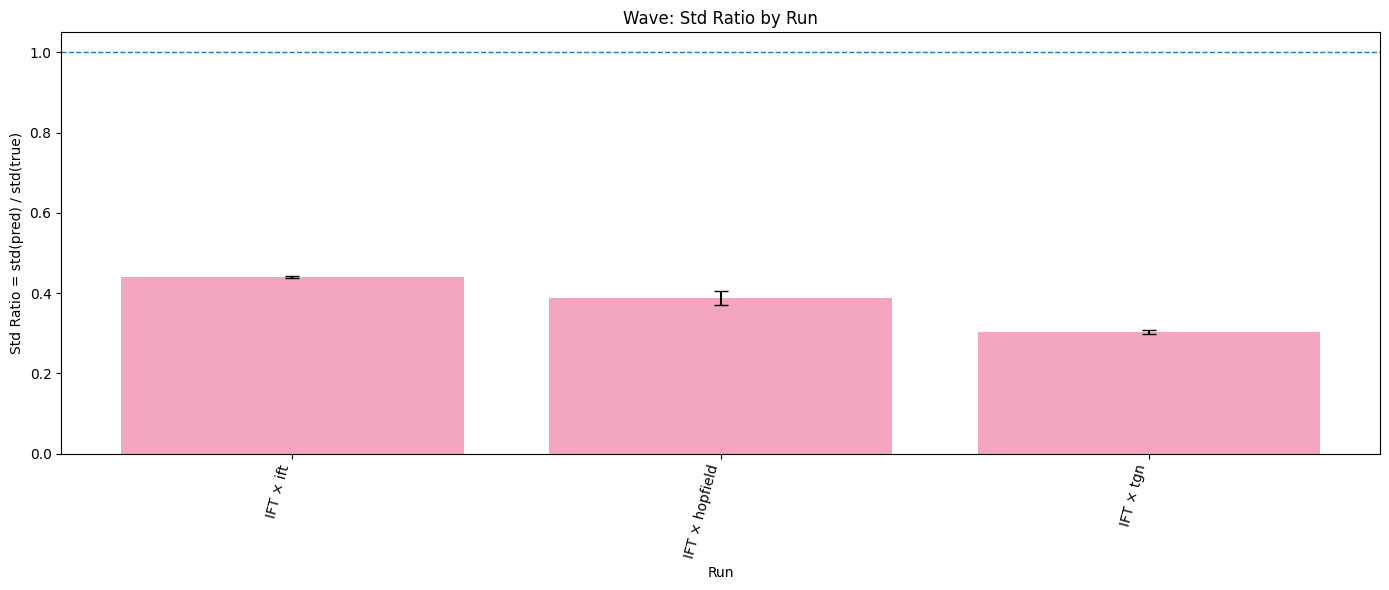

In [307]:
import matplotlib.pyplot as plt

plot_df = combo_ratio_df.copy()

plt.figure(figsize=(14, 6))
plt.bar(
    plot_df["model_combo"], 
    plot_df["avg_std_ratio"], 
    yerr=plot_df["std_std_ratio"].fillna(0.0),
    capsize=5,
    color="#f4a6c1"
)
plt.axhline(1.0, linestyle="--", linewidth=1)  # ideal amplitude match
plt.ylabel("Std Ratio = std(pred) / std(true)")
plt.xlabel("Run")
plt.title("Wave: Std Ratio by Run")
plt.xticks(rotation=75, ha="right")
plt.tight_layout()
plt.show()

In [308]:
combo_slope_df = (
    metrics_df
    .groupby("model_combo", as_index=False)
    .agg(
        avg_slope=("slope", "mean"),
        std_slope=("slope", "std"),
        n_files=("file", "count"),
    )
    .sort_values("avg_slope", ascending=False)
    .reset_index(drop=True)
)

combo_slope_df

,model_combo,avg_slope,std_slope,n_files
0,IFT × ift,0.173426,0.000697,3
1,IFT × hopfield,0.094289,0.003325,3
2,IFT × tgn,0.086623,0.001734,3


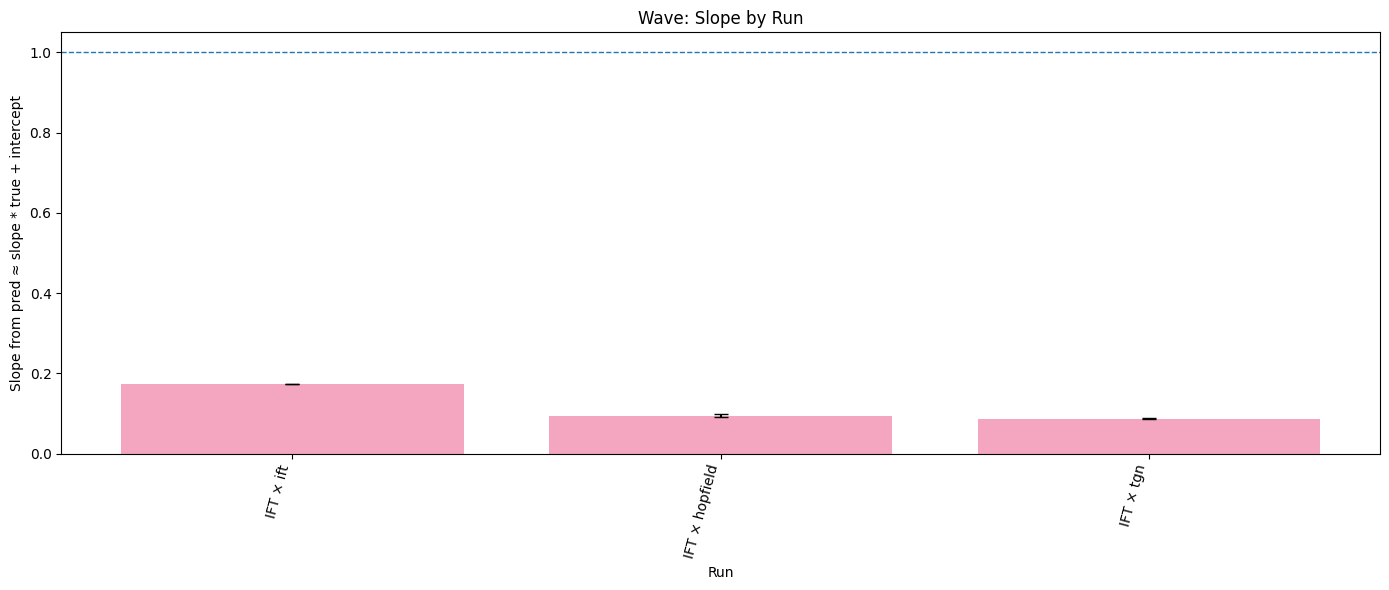

In [309]:
plot_df = combo_slope_df.copy()

plt.figure(figsize=(14, 6))
plt.bar(
    plot_df["model_combo"], 
    plot_df["avg_slope"], 
    yerr=plot_df["std_slope"].fillna(0.0),
    capsize=5,
    color="#f4a6c1"
)

plt.axhline(1.0, linestyle="--", linewidth=1)  # ideal calibration
plt.ylabel("Slope from pred ≈ slope * true + intercept")
plt.xlabel("Run")
plt.title("Wave: Slope by Run")
plt.xticks(rotation=75, ha="right")
plt.tight_layout()
plt.show()